In [4]:
import sys
from pathlib import Path

# make the project root importable when the notebook runs from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

from src.data.data_loader import DataLoader

In [5]:
loader = DataLoader()

# ~10 years of daily SPX history; end=today+1 because yfinance end is exclusive
spx = loader.load_spx(
    start="2016-01-01",
    end=str(dt.date.today() + dt.timedelta(days=1)),
    interval="1d",
)

# yfinance returns MultiIndex columns even for one ticker -> flatten
if isinstance(spx.columns, pd.MultiIndex):
    spx.columns = spx.columns.droplevel(1)

S0 = float(spx["Close"].iloc[-1])   # spot anchor for the snapshot
print(spx.shape, "  S0 =", S0)
spx.tail()

[*********************100%***********************]  1 of 1 completed

(2622, 5)   S0 = 7411.58984375


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-06-02,7609.779785,7620.899902,7582.990234,7595.399902,5904410000
2026-06-03,7553.680176,7605.350098,7551.220215,7605.310059,5753860000
2026-06-04,7584.310059,7598.189941,7516.540039,7516.540039,5398910000
2026-06-05,7383.740234,7541.810059,7368.629883,7537.359863,5591290000
2026-06-08,7411.589844,7466.810059,7407.720215,7440.569824,1801188387


In [ ]:
chain = pd.read_parquet(ROOT / "data" / "spx_option_chain.parquet")

# --- prep: keep calls, build a clean mid price and time-to-maturity ---
calls = chain[chain["type"] == "call"].copy()

# mid price is more reliable than lastPrice; fall back if bid/ask missing
if {"bid", "ask"}.issubset(calls.columns):
    calls["mid"] = (calls["bid"] + calls["ask"]) / 2
    calls.loc[calls["mid"] <= 0, "mid"] = calls["lastPrice"]
else:
    calls["mid"] = calls["lastPrice"]

# time to maturity in YEARS
calls["ttm"] = (pd.to_datetime(calls["expiry"]) - pd.Timestamp.today()).dt.days / 365

# basic liquidity / sanity filter
calls = calls[(calls["mid"] > 0) & (calls["ttm"] > 0)].dropna(subset=["strike", "mid", "ttm"])
print(calls.shape)
calls.head()

(593, 18)


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,expiry,type,mid,ttm
781,SPXW260610C03000000,1970-01-01 00:29:38+00:00,3000.0,4426.53,4442.4,4461.4,0.0,0.0,NaN,1,6.386477,True,REGULAR,USD,2026-06-10,call,4451.90,0.00274
782,SPXW260610C04400000,1970-01-01 00:29:40+00:00,4400.0,3105.88,3043.0,3061.7,0.0,0.0,1.0,1,3.974182,True,REGULAR,USD,2026-06-10,call,3052.35,0.00274
783,SPXW260610C05400000,1970-01-01 00:29:40+00:00,5400.0,2081.58,2043.3,2062.0,0.0,0.0,1.0,1,2.655368,True,REGULAR,USD,2026-06-10,call,2052.65,0.00274
784,SPXW260610C05600000,1970-01-01 00:29:40+00:00,5600.0,1883.08,1843.2,1862.0,0.0,0.0,2.0,2,2.413304,True,REGULAR,USD,2026-06-10,call,1852.60,0.00274
785,SPXW260610C06575000,1970-01-01 00:29:38+00:00,6575.0,902.03,868.8,888.2,0.0,0.0,NaN,2,1.295749,True,REGULAR,USD,2026-06-10,call,878.50,0.00274


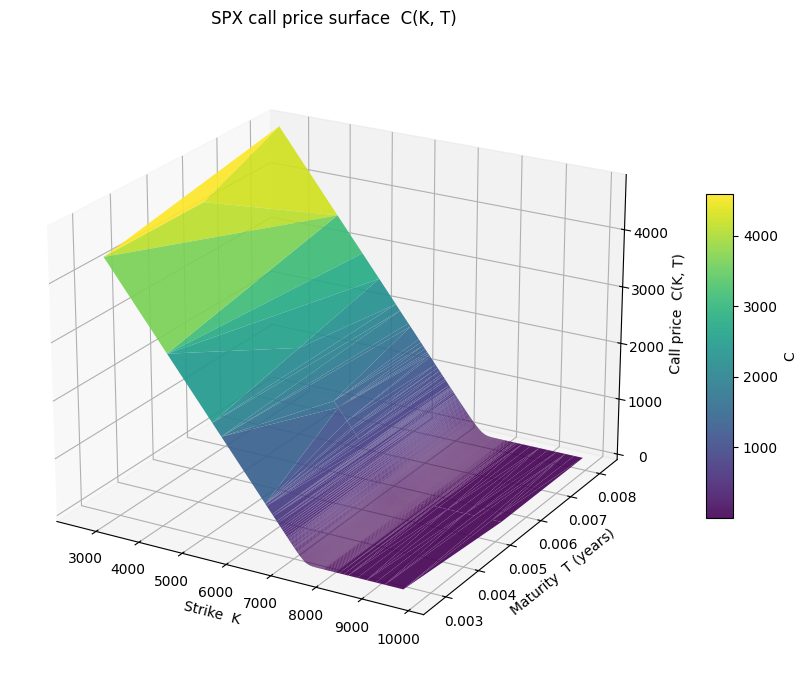

In [8]:
# ---- C(K, T) call price surface ----
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_trisurf(
    calls["strike"], calls["ttm"], calls["mid"],
    cmap=cm.viridis, edgecolor="none", alpha=0.9,
)
ax.set_xlabel("Strike  K")
ax.set_ylabel("Maturity  T (years)")
ax.set_zlabel("Call price  C(K, T)")
ax.set_title("SPX call price surface  C(K, T)")
fig.colorbar(surf, shrink=0.5, aspect=12, label="C")
ax.view_init(elev=22, azim=-60)
fig.tight_layout()
plt.show()

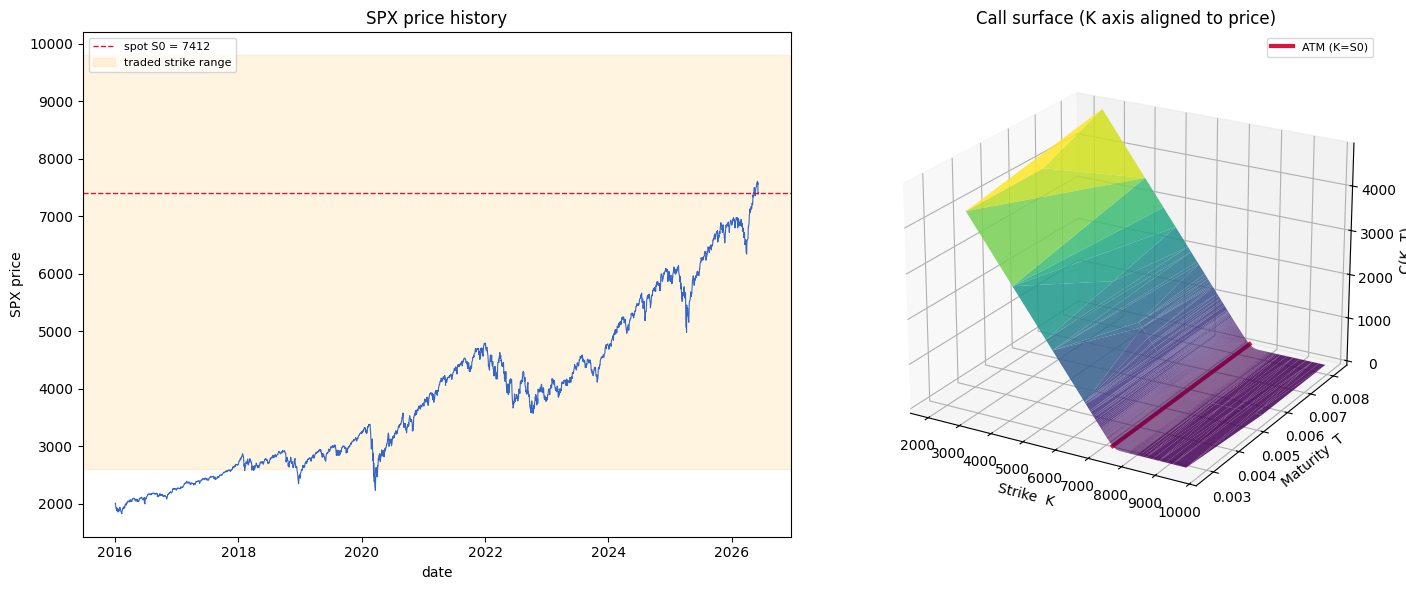

In [9]:
# ---- surface matched to the price series ----
# Left: price history (y-axis = price). Right: surface with its STRIKE axis
fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(spx.index, spx["Close"], lw=0.8, color="#3366cc")
ax1.axhline(S0, color="crimson", ls="--", lw=1, label=f"spot S0 = {S0:.0f}")
ax1.axhspan(calls["strike"].min(), calls["strike"].max(), color="orange",
            alpha=0.12, label="traded strike range")
ax1.set_xlabel("date"); ax1.set_ylabel("SPX price")
ax1.set_title("SPX price history"); ax1.legend(loc="upper left", fontsize=8)
price_range = ax1.get_ylim()

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_trisurf(calls["strike"], calls["ttm"], calls["mid"], cmap=cm.viridis, alpha=0.85)
# ATM ridge: C at K=S0 across maturities
ttm_sorted = sorted(calls["ttm"].unique())
atm = [np.interp(S0, g["strike"], g["mid"]) for _, g in calls.sort_values("strike").groupby("ttm")]
ax2.plot([S0] * len(atm), ttm_sorted, atm, color="crimson", lw=3, label="ATM (K=S0)")
ax2.set_xlim(price_range)               # strike axis aligned to the price y-axis
ax2.set_xlabel("Strike  K"); ax2.set_ylabel("Maturity  T"); ax2.set_zlabel("C(K, T)")
ax2.set_title("Call surface (K axis aligned to price)")
ax2.legend(fontsize=8); ax2.view_init(elev=22, azim=-60)

fig.tight_layout()
plt.show()